In [1]:
import sys
sys.path.insert(0, "..")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
from collections import Counter

# Project loaders
from src.data.load_data import load_arxiv_pyg, load_ddi_pyg

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.dpi"] = 130
print("✓ Imports ready")

d:\graph-ml-gnn-analysis\.venv\Lib\site-packages\outdated\__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
d:\graph-ml-gnn-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports ready


In [2]:
data_arxiv, split_idx, evaluator = load_arxiv_pyg(root="../data/raw")
data_ddi, split_edge, _ = load_ddi_pyg(root="../data/raw")
print("✓ Both datasets loaded")

Downloaded 0.08 GB: 100%|████████████████████████████████████████████████████████████████| 81/81 [01:09<00:00,  1.17it/s]


Extracting ../data/raw\arxiv.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 3084.05it/s]


...

Converting graphs into PyG objects...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2859.10it/s]

Saving...



Done!
d:\graph-ml-gnn-analysis\.venv\Lib\site-packages\torch\serialization.py:1865: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  result = unpickler.load()


[PyG] ogbl-ddi | Nodes: 4,267 | Edges: 2,135,822 | Node features: NONE (use embeddings)
✓ Both datasets loaded


In [3]:
summary = pd.DataFrame({
    "Dataset":    ["ogbn-arxiv", "ogbl-ddi"],
    "Task":       ["Node Classification", "Link Prediction"],
    "Nodes":      [f"{data_arxiv.num_nodes:,}", f"{data_ddi.num_nodes:,}"],
    "Edges":      [f"{data_arxiv.num_edges:,}", f"{data_ddi.num_edges:,}"],
    "Features":   [str(data_arxiv.num_node_features), "None (embeddings)"],
    "Classes":    ["40 (CS subfields)", "Binary (interacts?)"],
    "Train Split":[f"{len(split_idx['train']):,} nodes",
                   f"{len(split_edge['train']['edge']):,} edges"],
})
summary.set_index("Dataset", inplace=True)
summary

,Task,Nodes,Edges,Features,Classes,Train Split
Dataset,,,,,,
ogbn-arxiv,Node Classification,"169,343","1,166,243",128,40 (CS subfields),"90,941 nodes"
ogbl-ddi,Link Prediction,"4,267","2,135,822",None (embeddings),Binary (interacts?),"1,067,911 edges"


In [5]:
import os; os.makedirs("../reports/figures", exist_ok=True)

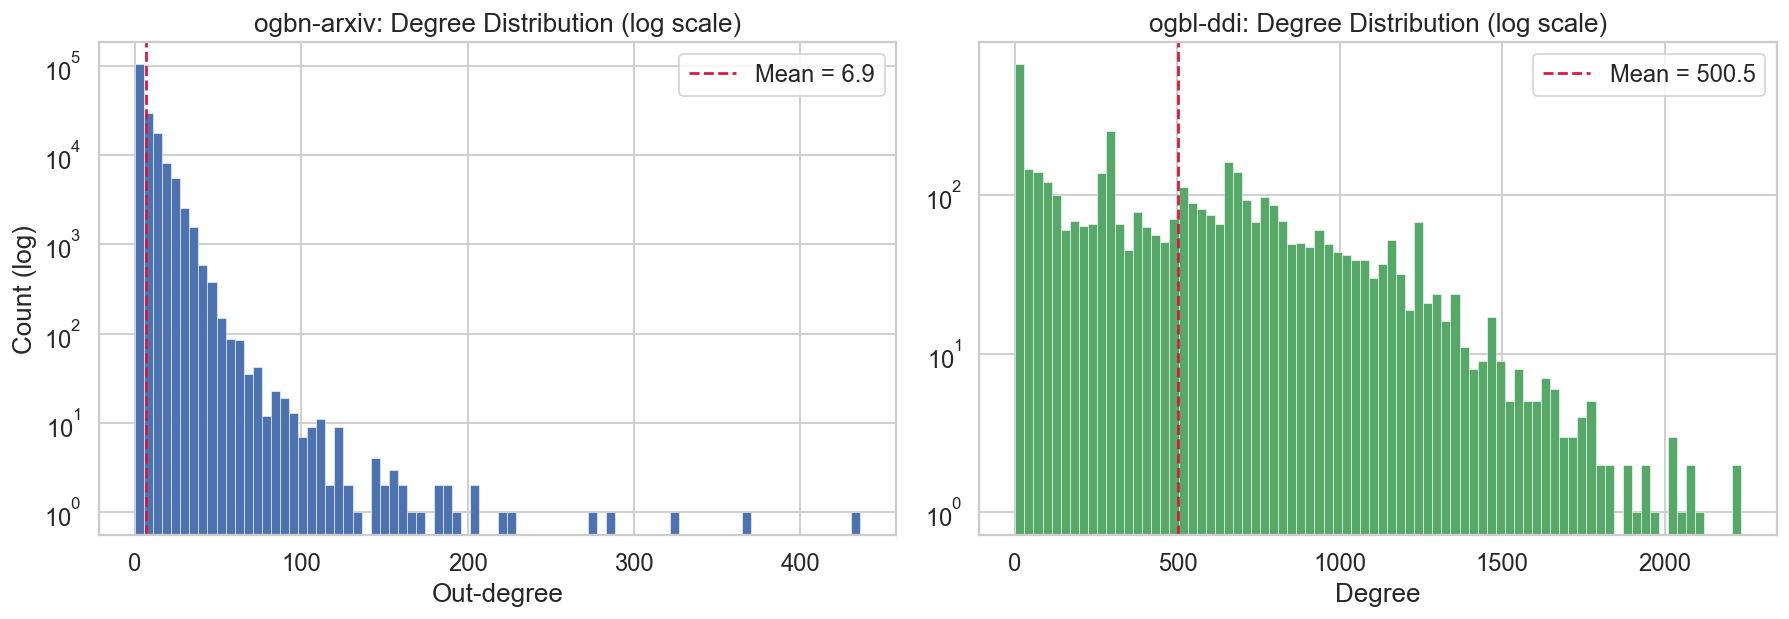

arxiv  — mean: 6.9, max: 436, median: 4
ddi    — mean: 500.5, max: 2234, median: 446


In [6]:
from torch_geometric.utils import degree

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# arxiv
deg_arxiv = degree(data_arxiv.edge_index[0], num_nodes=data_arxiv.num_nodes).numpy()
axes[0].hist(deg_arxiv, bins=80, color="#4C72B0", edgecolor="white", linewidth=0.3, log=True)
axes[0].set_title("ogbn-arxiv: Degree Distribution (log scale)")
axes[0].set_xlabel("Out-degree")
axes[0].set_ylabel("Count (log)")
axes[0].axvline(deg_arxiv.mean(), color="crimson", linestyle="--",
                label=f"Mean = {deg_arxiv.mean():.1f}")
axes[0].legend()

# ddi
deg_ddi = degree(data_ddi.edge_index[0], num_nodes=data_ddi.num_nodes).numpy()
axes[1].hist(deg_ddi, bins=80, color="#55A868", edgecolor="white", linewidth=0.3, log=True)
axes[1].set_title("ogbl-ddi: Degree Distribution (log scale)")
axes[1].set_xlabel("Degree")
axes[1].axvline(deg_ddi.mean(), color="crimson", linestyle="--",
                label=f"Mean = {deg_ddi.mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/degree_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"arxiv  — mean: {deg_arxiv.mean():.1f}, max: {deg_arxiv.max():.0f}, "
      f"median: {np.median(deg_arxiv):.0f}")
print(f"ddi    — mean: {deg_ddi.mean():.1f}, max: {deg_ddi.max():.0f}, "
      f"median: {np.median(deg_ddi):.0f}")

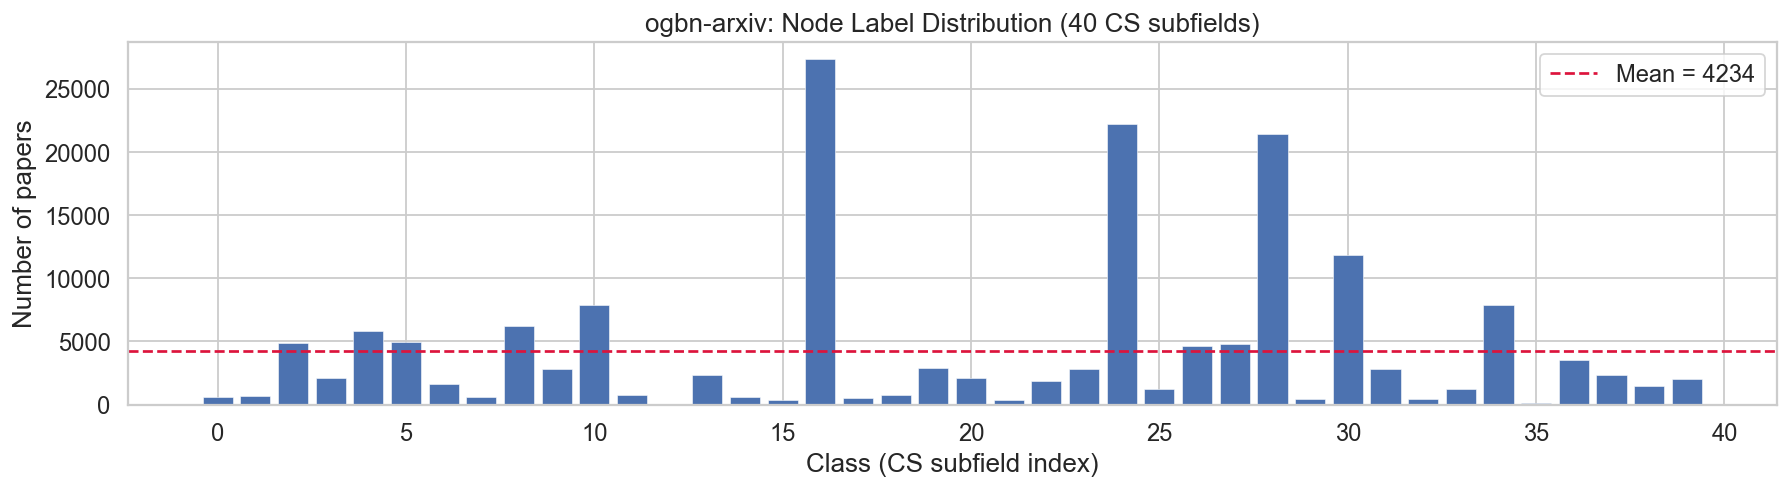

Most common class:  16 (27,321 nodes)
Least common class: 12 (29 nodes)
Class imbalance ratio: 942.1x


In [7]:
labels = data_arxiv.y.squeeze().numpy()
label_counts = Counter(labels)
sorted_counts = sorted(label_counts.items())

xs, ys = zip(*sorted_counts)

plt.figure(figsize=(14, 4))
bars = plt.bar(xs, ys, color="#4C72B0", edgecolor="white", linewidth=0.3)
plt.xlabel("Class (CS subfield index)")
plt.ylabel("Number of papers")
plt.title("ogbn-arxiv: Node Label Distribution (40 CS subfields)")
plt.axhline(np.mean(ys), color="crimson", linestyle="--",
            label=f"Mean = {np.mean(ys):.0f}")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Most common class:  {max(label_counts, key=label_counts.get)} "
      f"({max(label_counts.values()):,} nodes)")
print(f"Least common class: {min(label_counts, key=label_counts.get)} "
      f"({min(label_counts.values()):,} nodes)")
print(f"Class imbalance ratio: {max(label_counts.values())/min(label_counts.values()):.1f}x")

C:\Users\devso\AppData\Local\Temp\ipykernel_4388\174504188.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\devso\AppData\Local\Temp\ipykernel_4388\174504188.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("../reports/figures/feature_statistics.png", dpi=150, bbox_inches="tight")
d:\graph-ml-gnn-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


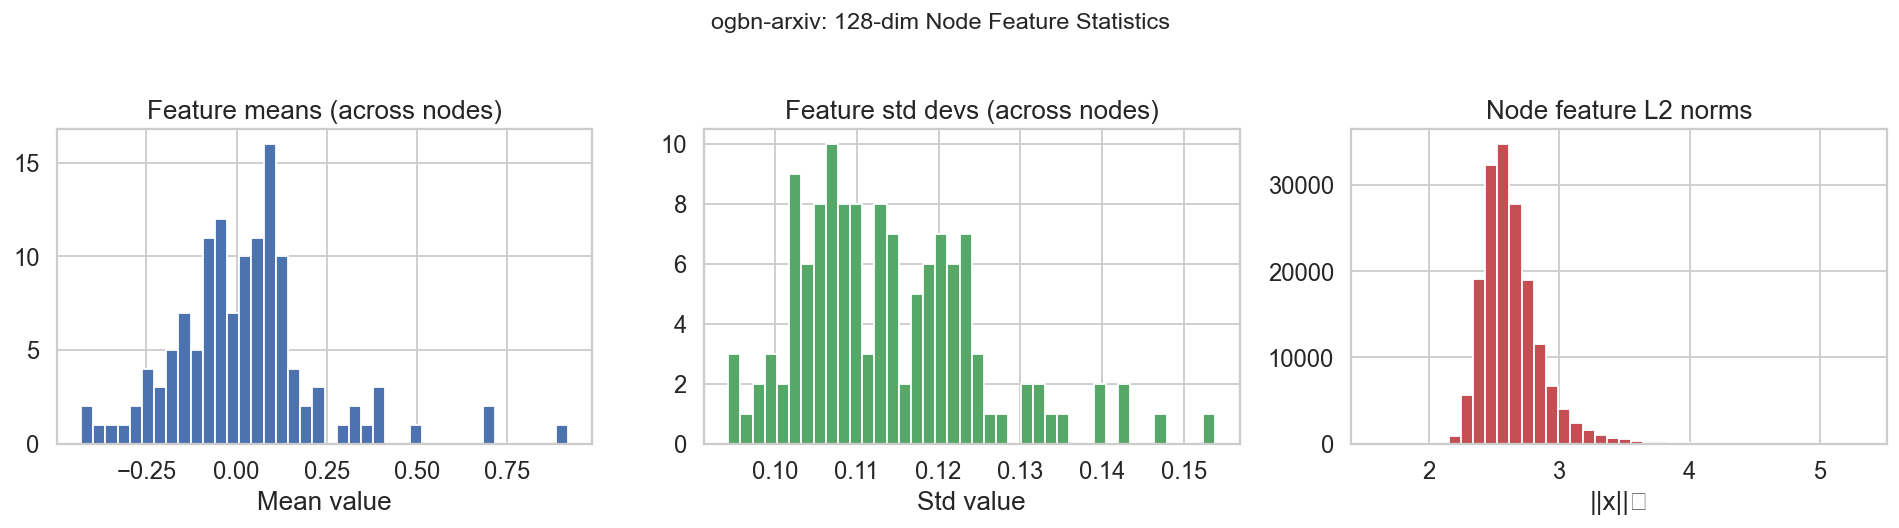

Feature dim: 128 | Global mean: 0.0205 | Global std: 0.2332


In [8]:
x = data_arxiv.x.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Feature mean distribution
axes[0].hist(x.mean(axis=0), bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Feature means (across nodes)")
axes[0].set_xlabel("Mean value")

# Feature std distribution
axes[1].hist(x.std(axis=0), bins=40, color="#55A868", edgecolor="white")
axes[1].set_title("Feature std devs (across nodes)")
axes[1].set_xlabel("Std value")

# Node-level L2 norm
norms = np.linalg.norm(x, axis=1)
axes[2].hist(norms, bins=40, color="#C44E52", edgecolor="white")
axes[2].set_title("Node feature L2 norms")
axes[2].set_xlabel("||x||₂")

plt.suptitle("ogbn-arxiv: 128-dim Node Feature Statistics", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/feature_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Feature dim: {x.shape[1]} | "
      f"Global mean: {x.mean():.4f} | "
      f"Global std: {x.std():.4f}")

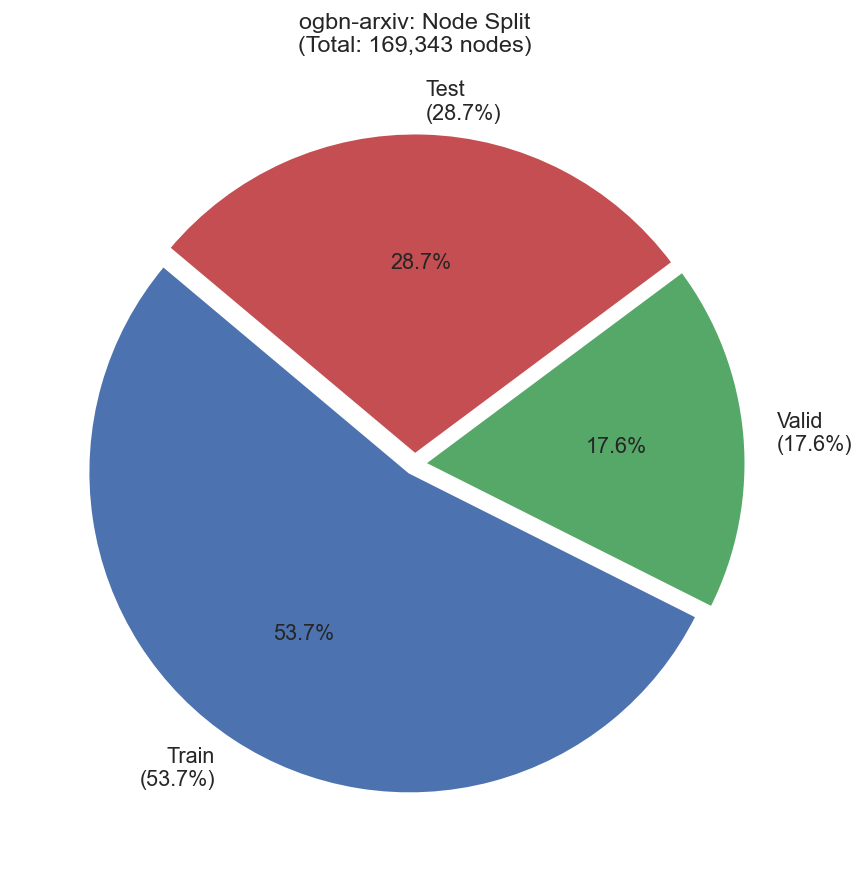

In [9]:
total = data_arxiv.num_nodes
train_n = len(split_idx["train"])
valid_n = len(split_idx["valid"])
test_n  = len(split_idx["test"])

labels_pie = ["Train\n(53.7%)", "Valid\n(17.6%)", "Test\n(28.7%)"]
sizes  = [train_n, valid_n, test_n]
colors = ["#4C72B0", "#55A868", "#C44E52"]
explode = (0.03, 0.03, 0.03)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_pie, colors=colors, explode=explode,
    autopct="%1.1f%%", startangle=140,
    textprops={"fontsize": 12},
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"}
)
ax.set_title(f"ogbn-arxiv: Node Split\n(Total: {total:,} nodes)", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

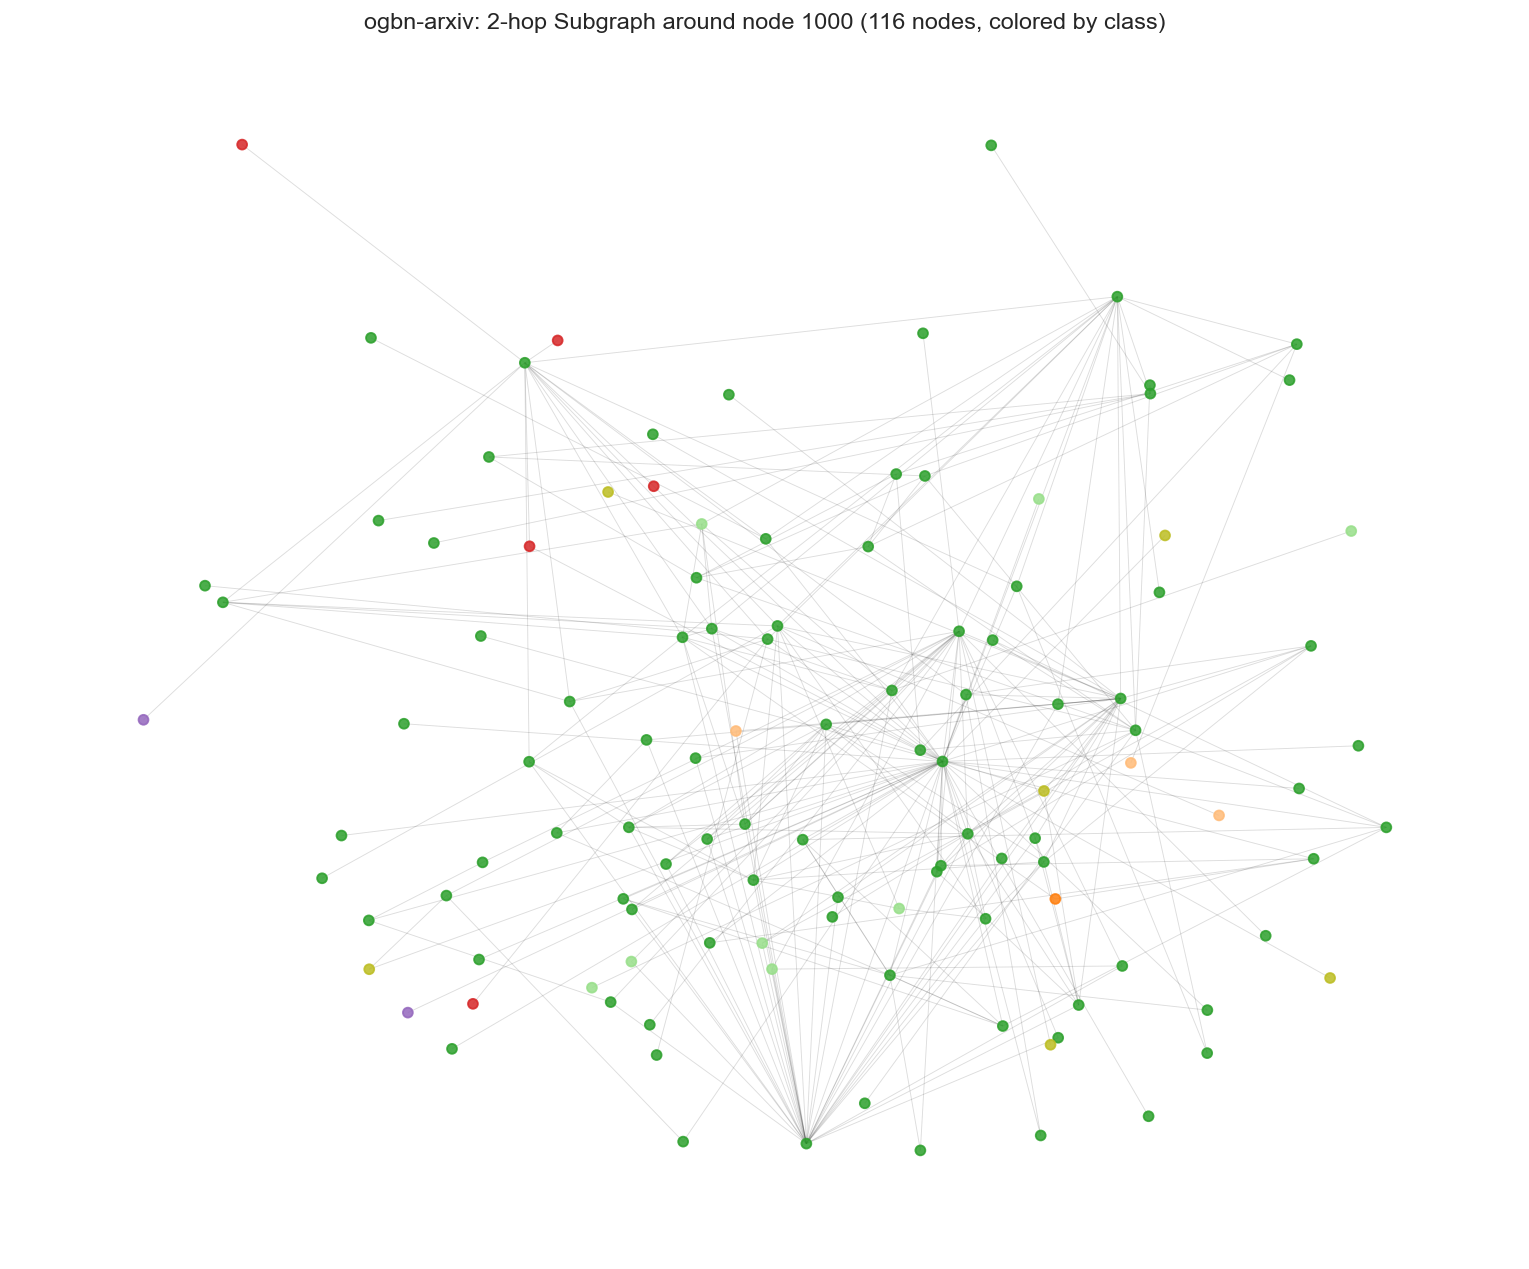

Subgraph: 116 nodes, 264 edges


In [10]:
# Sample a connected subgraph around a random seed node
torch.manual_seed(42)
seed = 1000
num_hops = 2

from torch_geometric.utils import k_hop_subgraph
subset, sub_edge_index, _, _ = k_hop_subgraph(
    node_idx=seed,
    num_hops=num_hops,
    edge_index=data_arxiv.edge_index,
    relabel_nodes=True,
    num_nodes=data_arxiv.num_nodes,
)

# Limit to 300 nodes for visibility
if subset.size(0) > 300:
    keep = subset[:300]
    mask = (sub_edge_index[0] < 300) & (sub_edge_index[1] < 300)
    sub_edge_index = sub_edge_index[:, mask]

sub_labels = data_arxiv.y[subset[:min(300, subset.size(0))]].squeeze().numpy()

# Build NetworkX graph
G = nx.DiGraph()
G.add_nodes_from(range(len(sub_labels)))
G.add_edges_from(sub_edge_index.t().numpy())

pos = nx.spring_layout(G, seed=42, k=0.4)
node_colors = [plt.cm.tab20(l % 20) for l in sub_labels]

plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.15, arrows=False, width=0.5)
plt.title(f"ogbn-arxiv: 2-hop Subgraph around node {seed} "
          f"({G.number_of_nodes()} nodes, colored by class)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/subgraph_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Subgraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

ogbn-arxiv Graph Statistics
                                        ogbn-arxiv
Property                                          
Nodes                                      169,343
Edges                                    1,166,243
Avg Degree                                    6.89
Max Degree                                     436
Graph Density                             4.07e-05
Degree Gini (inequality)                    0.5767
Feature Dim                                    128
Num Classes                                     40
Train / Val / Test        90,941 / 29,799 / 48,603


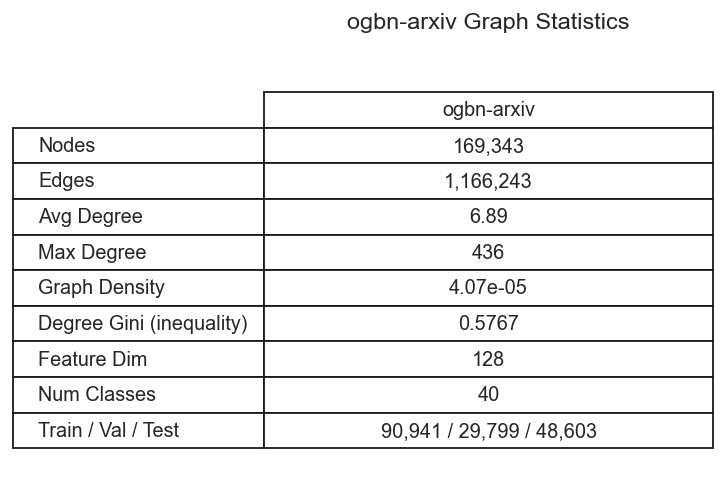

In [12]:
# Compute key graph properties
edge_index = data_arxiv.edge_index.numpy()
N = data_arxiv.num_nodes
E = data_arxiv.num_edges

avg_deg       = E / N
density       = E / (N * (N - 1))
deg_arr       = deg_arxiv
def gini_coefficient(arr):
    arr = np.sort(arr.astype(np.float64))
    n = len(arr)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * arr)) / (n * arr.sum()) - (n + 1) / n

gini = gini_coefficient(deg_arr)

stats = pd.DataFrame({
    "Property": [
        "Nodes", "Edges", "Avg Degree", "Max Degree",
        "Graph Density", "Degree Gini (inequality)",
        "Feature Dim", "Num Classes",
        "Train / Val / Test"
    ],
    "ogbn-arxiv": [
        f"{N:,}", f"{E:,}", f"{avg_deg:.2f}", f"{int(deg_arxiv.max())}",
        f"{density:.2e}", f"{gini:.4f}",
        "128", "40",
        f"{train_n:,} / {valid_n:,} / {test_n:,}"
    ]
})
stats.set_index("Property", inplace=True)

print("=" * 50)
print("ogbn-arxiv Graph Statistics")
print("=" * 50)
print(stats.to_string())
plt.figure(figsize=(7, 4))
plt.axis("off")
tbl = plt.table(
    cellText=stats.values, rowLabels=stats.index,
    colLabels=stats.columns, cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.6)
plt.title("ogbn-arxiv Graph Statistics", fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("../reports/figures/graph_statistics_table.png", dpi=150, bbox_inches="tight")
plt.show()